In [earlier work](https://dl.acm.org/doi/abs/10.1145/3735654.3735946), we
translated neural networks of a specific structure (1 input neuron, 1 output
neuron, 1 hidden layer) to the piece-wise linear function they represent. We
will expand LRA with a function symbol representing such networks, which can
then be verified using our framework.

In [1]:
import duckdb as db
import util.smtlib as smtlib

DBNAME = "dbs/nnv.db"

## Formal Verification

Consider the absolute value function, $F(x) = |x|$. This is a piece-wise linear
function (PWL) defined as follows:


$
F(x) = \begin{cases} 
    - & \text{if } x < 0 \\
    x & \text{if } x \geq 0 
\end{cases}
$

Say we want to formally verify if this function is always positive. We do this
by encoding it to LRA and performing quantifier elimination, using the function
symbol $F$ to represent the function:

$\forall x . F(x) > 0$

We can't perform a cylindrical decomposition on this as-is, we first have to do
some compilation steps. First, we introduce a new variable to represent the
function output. 

$\forall x \forall z\ .\ (F(x) = z) \rightarrow (z > 0)$

Now we translate $F(x)$. We can encode any PWL by using its breakpoints to
specify implications from the $x$-range to the output. In this case:

$(x<0 \rightarrow z=-x) \land (x>=0 \rightarrow z=x)$

Bringing the compiled function and the output constraint together:

$\forall x \forall z\ .\ (x<0 \rightarrow z=-x) \land (x>=0 \rightarrow z=x)$


`smtlib/abs_pwl.smt2` contains exactly this formula in SMT-LIB format.

In [2]:
with open("smtlib/abs_pwl.smt2", "r") as f:
    print(f.read())

(assert
    (forall ((x Real))
    (forall ((z Real))
        (=> (and (=> (< x 0) (= (+ z x) 0))
                 (=> (>= x 0) (= (- z x) 0)))
            (>= z 0)))))



We can evaluate this in SQL:

In [3]:
with db.connect(DBNAME) as con:
    result = smtlib.evaluate_smtlib_formula(con, "smtlib/abs_pwl.smt2")
    display(result)

Evaluating ∀x ∀z (((x < 0) ⟶ (z + x = 0)) ∧ ((x >= 0) ⟶ (z - x = 0))) ⟶ (z >= 0)


┌─────────────┬────────┬────────┐
│ truth_value │   x    │   z    │
│   boolean   │ double │ double │
├─────────────┼────────┼────────┤
│ true        │   -1.0 │   -2.0 │
└─────────────┴────────┴────────┘

The idea now is that we allow SMT-LIB formulas like this to achieve the same
thing:

```lisp
(declare-fun F (Real) Real)

(assert
    (forall ((x Real))
    (>= (F x) 0)))
```

Additionally, we won't work with PWLs directly, but instead with neural
networks.

## Neural Network PWLs

Let's train a small neural network that represents some trivial function. It has
the following requirements:

- 1 input node, 1 output node
- 1 hidden node (of any width)
- ReLU activation functions

We train the network to be $f(x)=x$ for $0<x5$ and $f(x)=-x$ for $5<x<10$ and
$0$ otherwise.

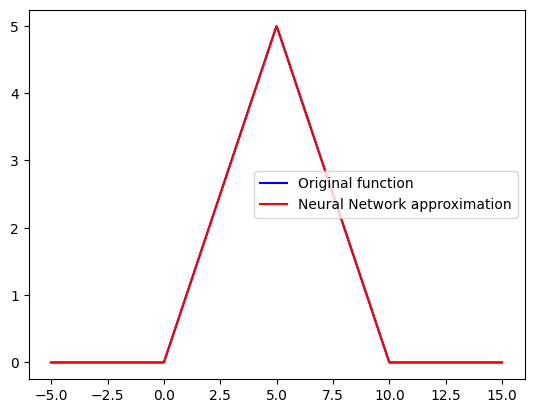

In [4]:
import torch
import torch.onnx
import numpy as np
import matplotlib.pyplot as plt
import util.nn as nn

torch.manual_seed(110033)

def f(x):
    if x < 0:
        return 0
    elif 0 <= x < 5:
        return x
    elif 5 <= x < 10:
        return 10-x
    else:
        return 0

x_train = np.linspace(-5, 15, 1000)
y_train = np.array([f(x) for x in x_train])

model = nn.ReLUFNN(input_size=1, output_size=1, hidden_size=3, num_hidden_layers=1)
nn.train(model, x_train, y_train, save_path="models/integral_geometric.pt")

model.eval()
with torch.no_grad():
    predicted = model(torch.tensor(x_train, dtype=torch.float32).unsqueeze(1)).detach().numpy()

plt.plot(x_train, y_train, 'b', label='Original function')
plt.plot(x_train, predicted, 'r', label='Neural Network approximation')
plt.legend()
plt.show()

As we can see, this model very closely approximates the target function.

Getting the PWL represented by the neural network is done leveraging our early
work, which assumes the model is stored in a database as a list of nodes and
edges. Let's do this using some utility code.

In [5]:
with db.connect(DBNAME) as con:
    nn.load_pytorch_model_into_db(con, model)

    display(con.sql("SELECT * FROM node"))
    display(con.sql("SELECT * FROM edge"))

┌───────┬─────────────────┬────────────────────────────┐
│  id   │      bias       │            name            │
│ int32 │      float      │          varchar           │
├───────┼─────────────────┼────────────────────────────┤
│     1 │             0.0 │ input.0                    │
│     2 │       3.4990025 │ linear_relu_stack.0.bias.0 │
│     3 │       3.4577518 │ linear_relu_stack.0.bias.1 │
│     4 │ -1.48762565e-05 │ linear_relu_stack.0.bias.2 │
│     5 │   2.4511532e-05 │ linear_relu_stack.2.bias.0 │
└───────┴─────────────────┴────────────────────────────┘

┌───────┬───────┬─────────────┐
│  src  │  dst  │   weight    │
│ int32 │ int32 │    float    │
├───────┼───────┼─────────────┤
│     1 │     2 │ -0.34989724 │
│     1 │     3 │  -0.6915605 │
│     1 │     4 │  -1.4708194 │
│     2 │     5 │   2.8578556 │
│     3 │     5 │  -2.8919547 │
│     4 │     5 │   0.6798905 │
└───────┴───────┴─────────────┘

We can now execute a SQL query to fetch the list of breakpoints and slopes that
represent the network's PWL:

In [6]:
with open('queries/nn/geometric.sql') as f:
    geometric_query = f.read()

with db.connect(DBNAME) as con:
    display(con.sql(geometric_query))

┌────────────────┬────────────────┬───────────────────────┬─────────────────────────┐
│       x1       │       x2       │         slope         │        intercept        │
│     float      │     float      │        double         │         double          │
├────────────────┼────────────────┼───────────────────────┼─────────────────────────┤
│    -10.0000105 │ -1.0114265e-05 │ 9.720917195643608e-06 │ -3.2737803176728164e-06 │
│ -1.0114265e-05 │      4.9999266 │    1.0000059057004853 │   6.840442461398069e-06 │
│      4.9999266 │      10.000086 │   -0.9999558133596896 │       9.999668472024396 │
│      10.000086 │      20.000086 │                   0.0 │  2.4511531591997482e-05 │
└────────────────┴────────────────┴───────────────────────┴─────────────────────────┘

## Verifying Properties

Imagine we want to verify this property on the network:

$\forall x . F(x) < 10$

Behind the scenes, this would get compiled to:

$\forall x \forall z . F(x)=z \rightarrow z < 10$

However, the geometric representation is limited in that it does not handle
infinities. Instead, the function is bounded to a finite range (-10 to 10).
Let's explicitly add this to our verification query as well.

$\forall x \forall z . (x > -10 \land x < 10 \land F(x)=z \rightarrow z <
10)$

To translate $F(x)$, we use a conjunction of implications based on the segments.
For every pair of successive breakpoints $x_{start},x_{end}$ we get:

$x_{start} \le x \lt x_{end} \rightarrow a_0 + a_1x - z = 0$

This entire compilation is done in the Python glue code for now. Hopefully,
later iterations of our framework will use the geometrical representation all
within a SQL query.

Before we get to a general SMT-LIB approach, let's first see if we can manage to
verify our property using our own datastructures. First, we need a function to
compile a neural network. This assumes the database contains a single model

In [7]:
import util.formula as f
import util.sqlcad as sqlcad

def compile_function(con, input_var_name: str, output_var_name: str):
    """
    Assuming the database contains 1 model, compiles it to an LRA formula where
    with input `input_var_name` and output `output_var_name`.
    """
    function_terms = []
    for (x1, x2, slope, intercept) in con.execute(geometric_query).fetchall():
        a0 = intercept
        a1 = slope

        segment = f.Implies(
            # min/max constraint of line segment.
            f.And([
                f.InEq('>=', f.Sub([f.Var(input_var_name), f.Const(x1)])),
                f.InEq('<', f.Sub([f.Var(input_var_name), f.Const(x2)]))
            ]),
            # y = a0 + a1*x, so a0 + a1*x - y = 0
            f.InEq(
                '=',
                f.Add([
                    f.Const(a0),
                    f.Mult([f.Const(a1), f.Var(input_var_name)]),
                    f.Neg(f.Var(output_var_name))
                ]
            ))
        )

        function_terms.append(segment)

    return f.And(function_terms)


Now we use this method to compile our function $\forall x . (-10 < x < 10)
\rightarrow F(x) < 10$ and verify it:

In [8]:
with db.connect(DBNAME) as con:
    function = compile_function(con, 'x', 'z')

    # Merge the preconditions and the function representation as the antecedent.
    antecedent = f.And([
        f.InEq('>', f.Add([f.Var('x'), f.Const(10)])),
        f.InEq('<', f.Sub([f.Var('x'), f.Const(10)])),
        function
    ])
    postcondition = f.InEq('<', f.Sub([f.Var('z'), f.Const(10)]))

    full_formula = f.Implies(antecedent, postcondition)

    # Add quantifiers
    full_formula = f.Forall('x', f.Forall('z', full_formula))
    print(full_formula)

    display(sqlcad.evaluate_formula(con, full_formula))

∀x ∀z ((x + 10 > 0) ∧ (x - 10 < 0) ∧ ((((x - -10.00001049041748 >= 0) ∧ (x - -1.0114265023730695e-05 < 0)) ⟶ (-3.2737803176728164e-06 + 9.720917195643608e-06 * x + -z = 0)) ∧ (((x - -1.0114265023730695e-05 >= 0) ∧ (x - 4.999926567077637 < 0)) ⟶ (6.840442461398069e-06 + 1.0000059057004853 * x + -z = 0)) ∧ (((x - 4.999926567077637 >= 0) ∧ (x - 10.000085830688477 < 0)) ⟶ (9.999668472024396 + -0.9999558133596896 * x + -z = 0)) ∧ (((x - 10.000085830688477 >= 0) ∧ (x - 20.000085830688477 < 0)) ⟶ (2.4511531591997482e-05 + 0.0 * x + -z = 0)))) ⟶ (z - 10 < 0)


┌─────────────┬────────────────────┬────────────────────┐
│ truth_value │         x          │         z          │
│   boolean   │       double       │       double       │
├─────────────┼────────────────────┼────────────────────┤
│ true        │ -11.00001049041748 │ -12.00006861274231 │
└─────────────┴────────────────────┴────────────────────┘

This works! As a sanity check, let's do exactly the same but let's expect $z$ to
always be less than 4, which should be false.

In [9]:
with db.connect(DBNAME) as con:
    function = compile_function(con, 'x', 'z')

    antecedent = f.And([
        f.InEq('>', f.Add([f.Var('x'), f.Const(10)])),
        f.InEq('<', f.Sub([f.Var('x'), f.Const(10)])),
        function
    ])
    postcondition = f.InEq('<', f.Sub([f.Var('z'), f.Const(4)]))

    full_formula = f.Implies(antecedent, postcondition)

    full_formula = f.Forall('x', f.Forall('z', full_formula))
    print(full_formula)
    display(sqlcad.evaluate_formula(con, full_formula))

∀x ∀z ((x + 10 > 0) ∧ (x - 10 < 0) ∧ ((((x - -10.00001049041748 >= 0) ∧ (x - -1.0114265023730695e-05 < 0)) ⟶ (-3.2737803176728164e-06 + 9.720917195643608e-06 * x + -z = 0)) ∧ (((x - -1.0114265023730695e-05 >= 0) ∧ (x - 4.999926567077637 < 0)) ⟶ (6.840442461398069e-06 + 1.0000059057004853 * x + -z = 0)) ∧ (((x - 4.999926567077637 >= 0) ∧ (x - 10.000085830688477 < 0)) ⟶ (9.999668472024396 + -0.9999558133596896 * x + -z = 0)) ∧ (((x - 10.000085830688477 >= 0) ∧ (x - 20.000085830688477 < 0)) ⟶ (2.4511531591997482e-05 + 0.0 * x + -z = 0)))) ⟶ (z - 4 < 0)


┌─────────────┬────────┬────────┐
│ truth_value │   x    │   z    │
│   boolean   │ double │ double │
├─────────────┼────────┼────────┤
│ false       │   NULL │   NULL │
└─────────────┴────────┴────────┘

Great! Let's do another property. We check if the NN is monotonic for $0<x<5$,
which we expect to be the case. We use the ["correctness property"
notation](https://arxiv.org/abs/2109.10317) for this, where we first specify the
preconditions, followed by a series of network evaluations, and finally a series
of postconditions.

$$
\{0 < x < 5 \land 0 < x' < 5 \land x < x' \} \\
u \leftarrow F(x)\\
u' \leftarrow F(x')\\
\{u' > u\}
$$

Let's encode this again.

In [10]:
with db.connect(DBNAME) as con:

    antecedent = f.And([
        # 0 < x < 5
        f.InEq('>', f.Sub([f.Var('x'), f.Const(0)])),
        f.InEq('<', f.Sub([f.Var('x'), f.Const(4.9)])),
        # 0 < x' < 5
        f.InEq('>', f.Sub([f.Var('x_prime'), f.Const(0)])),
        f.InEq('<', f.Sub([f.Var('x_prime'), f.Const(4.9)])),
        # x < x'
        f.InEq('<', f.Sub([f.Var('x'), f.Var('x_prime')])),
        # The function calls
        compile_function(con, 'x', 'u'),
        compile_function(con, 'x_prime', 'u_prime'),
    ])

    postcondition = f.InEq('<', f.Sub([f.Var('u'), f.Var('u_prime')]))
    full_formula = f.Implies(antecedent, postcondition)

    full_formula = f.Forall(
        'x',
        f.Forall(
            'x_prime',
            f.Forall(
                'u',
                f.Forall(
                    'u_prime',
                    full_formula
                )
            )
        )
    )
    print(full_formula)
    display(sqlcad.evaluate_formula(con, full_formula))

∀x ∀x_prime ∀u ∀u_prime ((x - 0 > 0) ∧ (x - 4.9 < 0) ∧ (x_prime - 0 > 0) ∧ (x_prime - 4.9 < 0) ∧ (x - x_prime < 0) ∧ ((((x - -10.00001049041748 >= 0) ∧ (x - -1.0114265023730695e-05 < 0)) ⟶ (-3.2737803176728164e-06 + 9.720917195643608e-06 * x + -u = 0)) ∧ (((x - -1.0114265023730695e-05 >= 0) ∧ (x - 4.999926567077637 < 0)) ⟶ (6.840442461398069e-06 + 1.0000059057004853 * x + -u = 0)) ∧ (((x - 4.999926567077637 >= 0) ∧ (x - 10.000085830688477 < 0)) ⟶ (9.999668472024396 + -0.9999558133596896 * x + -u = 0)) ∧ (((x - 10.000085830688477 >= 0) ∧ (x - 20.000085830688477 < 0)) ⟶ (2.4511531591997482e-05 + 0.0 * x + -u = 0))) ∧ ((((x_prime - -10.00001049041748 >= 0) ∧ (x_prime - -1.0114265023730695e-05 < 0)) ⟶ (-3.2737803176728164e-06 + 9.720917195643608e-06 * x_prime + -u_prime = 0)) ∧ (((x_prime - -1.0114265023730695e-05 >= 0) ∧ (x_prime - 4.999926567077637 < 0)) ⟶ (6.840442461398069e-06 + 1.0000059057004853 * x_prime + -u_prime = 0)) ∧ (((x_prime - 4.999926567077637 >= 0) ∧ (x_prime - 10.0000858

┌─────────────┬─────────────────────┬────────────────────┬────────────────────┬─────────────────────┐
│ truth_value │          x          │      x_prime       │         u          │       u_prime       │
│   boolean   │       double        │       double       │       double       │       double        │
├─────────────┼─────────────────────┼────────────────────┼────────────────────┼─────────────────────┤
│ true        │ -1028716.6275482931 │ -105825683125.9919 │ 105821007055.59567 │ -105826308101.78009 │
└─────────────┴─────────────────────┴────────────────────┴────────────────────┴─────────────────────┘

Not that we specified $x < 4.9$ instead of $x < 5$. This because our neural
network is still just an approximation, and already starts decreasing ever so
slightly before x reaches 5.

We now look at a more interesting network. Consider a network with 100 hidden
nodes trained to approximate a sine function.

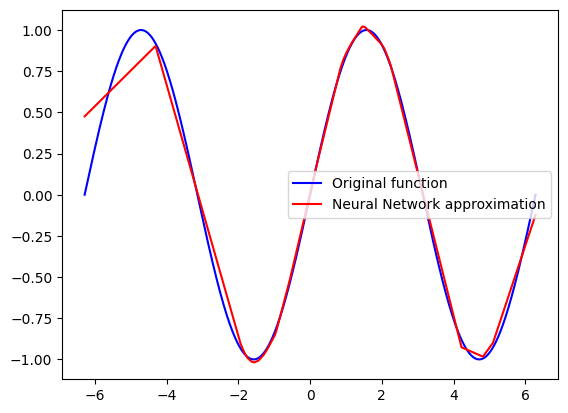

In [11]:
import math

torch.manual_seed(1)

x_train = np.linspace(-2*math.pi, 2*math.pi, 10000)
y_train = np.array([math.sin(x) for x in x_train])

sine_model = nn.ReLUFNN(input_size=1, output_size=1, hidden_size=100, num_hidden_layers=1)
nn.train(sine_model, x_train, y_train, epochs=400, save_path="models/integral_geometric_sine_mini.pt")

sine_model.eval()
with torch.no_grad():
    predicted = sine_model(torch.tensor(x_train, dtype=torch.float32).unsqueeze(1)).detach().numpy()

plt.plot(x_train, y_train, 'b', label='Original function')
plt.plot(x_train, predicted, 'r', label='Neural Network approximation')
plt.legend()
plt.show()

with db.connect(DBNAME) as con:
    nn.load_pytorch_model_into_db(con, sine_model)

We want to check if the output of the sine function always lies between -1 and 1
(with some small epsilon to account for the network's inaccuracies).

In [12]:
with db.connect(DBNAME) as con:
    antecedent = f.And([
        # -2 < x < 2
        f.InEq('>', f.Sub([f.Var('x'), f.Const(-2)])),
        f.InEq('<', f.Sub([f.Var('x'), f.Const(2)])),
        # The function call
        compile_function(con, 'x', 'z'),
    ])

    # -1.2 < z < 1.2
    postcondition = f.And([
        f.InEq('>', f.Sub([f.Var('z'), f.Const(-1.2)])),
        f.InEq('<', f.Sub([f.Var('z'), f.Const(1.2)]))
    ])
    full_formula = f.Implies(antecedent, postcondition)
    full_formula = f.Forall('x', f.Forall('z', full_formula))
    display(sqlcad.evaluate_formula(con, full_formula))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬─────────────────────┬─────────────────────┐
│ truth_value │          x          │          z          │
│   boolean   │       double        │       double        │
├─────────────┼─────────────────────┼─────────────────────┤
│ true        │ -1136.8552061023663 │ -1095.5905677214048 │
└─────────────┴─────────────────────┴─────────────────────┘

This is a bit slower, but still verifies our property as expected!

## Adding a Function Symbol

Now we want to allow users to provide an SMT-LIB formula with just a function
symbol $F$ to represent the network evaluation. Let's look at the basic model
again.

In [13]:
with db.connect(DBNAME) as con:
    nn.load_pytorch_model_into_db(con, model)

We will now verify the following property:

$\forall x . (x > 1 \land x < 9) \rightarrow F(x) > 0$

We expect the user to have loaded one or more models in the database already.
Our framework accepts the $F(x)$ symbol as-is, but we require the user to map
the function symbol to the ID of the relevant network in the database.

In this case we only have one model with ID 1:

In [14]:
smtlib_formula = """
(declare-fun F (Real) Real)

(assert
    (forall ((x Real))
    (=> (and (> (- x 1) 0)
             (< (- x 9) 0))
        (> (F x) 0))))
"""

with db.connect(DBNAME) as con:
    mapping = {'F': 1}
    formula = smtlib.parse_from_string(smtlib_formula)
    print(formula)
    display(sqlcad.evaluate_formula(con, formula, mapping))

∀x ((x - 1.0 > 0) ∧ (x - 9.0 < 0)) ⟶ (F(x) > 0)


┌─────────────┬────────────────────┐
│ truth_value │         x          │
│   boolean   │       double       │
├─────────────┼────────────────────┤
│ true        │ -11.00001049041748 │
└─────────────┴────────────────────┘

And as a sanity check, this should be false: ($\forall x . 1 < x < 9 \rightarrow
F(x) > 2$).

In [15]:
smtlib_formula = """
(declare-fun F (Real) Real)

(assert
    (forall ((x Real))
    (=> (and (> (- x 1) 0)
             (< (- x 9) 0))
        (> (- (F x) 2) 0))))
"""

with db.connect(DBNAME) as con:
    mapping = {'F': 1}
    formula = smtlib.parse_from_string(smtlib_formula)
    print(formula)
    display(sqlcad.evaluate_formula(con, formula, mapping))

∀x ((x - 1.0 > 0) ∧ (x - 9.0 < 0)) ⟶ (F(x) - 2.0 > 0)


┌─────────────┬────────┐
│ truth_value │   x    │
│   boolean   │ double │
├─────────────┼────────┤
│ false       │   NULL │
└─────────────┴────────┘

Multiple function calls are supported. E.g., checking for monotonicity:

$\forall x \forall x' . (1 < x < 4 \land 1 < x' < 4 \land x' > x) \rightarrow
F(x') > F(x)$

In [16]:
smtlib_formula = """
(declare-fun F (Real) Real)

(assert
    (forall ((x Real) (x_prime Real))
    (=> (and (> (- x 1) 0)
             (< (- x 4) 0)
             (> (- x_prime 1) 0)
             (< (- x_prime 4) 0)
             (> (- x_prime x) 0))
        (> (- (F x_prime) (F x)) 0))))
"""

with db.connect(DBNAME) as con:
    mapping = {'F': 1}
    formula = smtlib.parse_from_string(smtlib_formula)
    print(formula)
    display(sqlcad.evaluate_formula(con, formula, mapping))

∀x ∀x_prime ((x - 1.0 > 0) ∧ (x - 4.0 < 0) ∧ (x_prime - 1.0 > 0) ∧ (x_prime - 4.0 < 0) ∧ (x_prime - x > 0)) ⟶ (F(x_prime) - F(x) > 0)


┌─────────────┬─────────────────────┬────────────────────────┐
│ truth_value │          x          │        x_prime         │
│   boolean   │       double        │         double         │
├─────────────┼─────────────────────┼────────────────────────┤
│ true        │ -1028716.6275482931 │ -1.011426319545028e-05 │
└─────────────┴─────────────────────┴────────────────────────┘

Or even different function symbols. Let's say we want to check if two models
have identical output within some epsilon:

$\forall x . -0.1 < F(x) - G(x) < 0.1$

We rewrite this to our format and simply use the same model ID for F and G, so
surely we expect the result to be true.

In [17]:
smtlib_formula = """
(declare-fun F (Real) Real)
(declare-fun G (Real) Real)

(assert
    (forall ((x Real))
    (=> (and (> (- x -10) 0)
             (< (- x 10) 0))
        (and (> (+ 0.1 (F x) (- (G x))) 0)
             (< (+ -0.1 (F x) (- (G x))) 0)))))
"""

with db.connect(DBNAME) as con:
    mapping = {'F': 1, 'G': 1}
    formula = smtlib.parse_from_string(smtlib_formula)
    print(formula)
    display(sqlcad.evaluate_formula(con, formula, mapping))

∀x ((x - -10.0 > 0) ∧ (x - 10.0 < 0)) ⟶ ((0.1 + F(x) + -1.0 * G(x) > 0) ∧ (-0.1 + F(x) + -1.0 * G(x) < 0))


┌─────────────┬────────────────────┐
│ truth_value │         x          │
│   boolean   │       double       │
├─────────────┼────────────────────┤
│ true        │ -20572.33197037283 │
└─────────────┴────────────────────┘

## Extra examples

The paper concludes with 2 additional examples. The first one, check if the
network has a global maximum: $\exists m \forall x\ .\ F(m) > F(x)$. We check
this for a specific input range, as explained earlier. This makes the result
somewhat weak, since it makes sense for a bounded input range to have a maximum.

In [18]:
smtlib_formula = """
(declare-fun F (Real) Real)

(assert
    (exists ((m Real))
    (forall ((x Real))
    (=> (and (> (- x -10) 0)
             (< (- x 10) 0)
             (> (- m -10) 0)
             (< (- m 10) 0))

        (> (- (F m) (F x)) 0)))))
"""


with db.connect(DBNAME) as con:
    mapping = {'F': 1}
    formula = smtlib.parse_from_string(smtlib_formula)
    print(formula)
    display(sqlcad.evaluate_formula(con, formula, mapping))

∃m ∀x ((x - -10.0 > 0) ∧ (x - 10.0 < 0) ∧ (m - -10.0 > 0) ∧ (m - 10.0 < 0)) ⟶ (F(m) - F(x) > 0)


┌─────────────┬─────────────────────┬────────────────────┐
│ truth_value │          m          │         x          │
│   boolean   │       double        │       double       │
├─────────────┼─────────────────────┼────────────────────┤
│ true        │ -1028716.6275482931 │ -105825683125.9919 │
└─────────────┴─────────────────────┴────────────────────┘

And the second example, probably a bit more useful: given an input range for x,
what is the upper bound the network reaches? Or, $\forall x\ .\ F(x) < m$, again
for a specific input range.

In [22]:
smtlib_formula = """
(declare-fun F (Real) Real)
(declare-fun m () Real)

(assert
    (forall ((x Real))
    (=> (and (> (- x 0) 0)
             (< (- x 10) 0))

        (< (- (F x) m) 0))))
"""

with db.connect(DBNAME) as con:
    mapping = {'F': 1}
    formula = smtlib.parse_from_string(smtlib_formula)
    print(formula)
    display(sqlcad.evaluate_formula(con, formula, mapping))

∀x ((x - 0.0 > 0) ∧ (x - 10.0 < 0)) ⟶ (F(x) - m < 0)


┌─────────────┬───────────────────┬────────────────────┐
│ truth_value │         m         │         x          │
│   boolean   │      double       │       double       │
├─────────────┼───────────────────┼────────────────────┤
│ true        │ 4.999962935588852 │ -11.00001049041748 │
└─────────────┴───────────────────┴────────────────────┘

As we can see, this formula finds that such an upper bound exists. The sample
point returned isn't that useful, since it is one that makes the antecedent
false. Instead, we can query the generated sample points.

In [24]:
query = """
SELECT MIN(l1.x1) AS m,
FROM
(
    SELECT
        l2.base_cell,
        BOOL_AND (r.truth_value) AS truth_value,
    FROM
    (
        SELECT
            l3.base_cell,
            BOOL_AND (r.truth_value) AS truth_value
        FROM Result r
        JOIN Lift_Dimension3 l3 ON l3.id = r.cell_id
        GROUP BY l3.base_cell
    ) r
    JOIN Lift_Dimension2 l2 ON l2.id = r.base_cell
    GROUP BY l2.base_cell
) r
JOIN Lift_Dimension1 l1 ON l1.id = r.base_cell
WHERE r.truth_value
"""

with db.connect(DBNAME) as con:
    display(con.sql(query))

┌───────────────────┐
│         m         │
│      double       │
├───────────────────┤
│ 4.999962935588852 │
└───────────────────┘

This is still not necessarily the lowest bound, since it is a sample point, but
it will be close.

## Conclusion

Earlier we presented our SQL-based framework that is able to perform quantifier
elimination on LRA formulas. In this notebook, we extended LRA with additional
function symbols representing neural network evaluation. Our framework compiles
such formulas to a basic LRA version and uses our CAD implementation to verify
them.